## Quantum Reservoir Computing for Weather Prediction

This notebook applies **Quantum Reservoir Computing (QRC)** to predict daily mean temperature in Delhi using historical meteorological data.

**Dataset**: daily measurements of temperature (°C), humidity (%), wind speed (km/h), and atmospheric pressure (hPa) from 2013–2017 (`weather_train.csv` / `weather_test.csv`). The prediction target is `meantemp`, using the previous day's weather features as inputs.

**Circuit families tested**: G1, G2, G3, MG, Ising, D2_random, scrambling ansatz — sweeping gate depth, entanglement degree, and ansatz structure.
**Baselines**: naive forecast (tomorrow = today) and other classical time-series models.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import warnings; warnings.filterwarnings('ignore')

#from technical_analysis_indicators import get_regressor_vars
from QRC import  QuantumRC_Circuit

In [2]:
data_train = pd.read_csv('data/time_series/weather_train.csv')
data_test = pd.read_csv('data/time_series/weather_test.csv')
data = pd.concat([data_train, data_test], ignore_index=True)

print(f"Train shape: {data_train.shape}, Test shape: {data_test.shape}, Total shape: {data.shape}")
data.head()

Train shape: (1462, 5), Test shape: (114, 5), Total shape: (1576, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## Data Preprocessing and Train/Val/Test Split

The full dataset is split chronologically into three non-overlapping periods:
- **Train**: up to 2015-09-28 (1001 samples, ~64% of data)
- **Validation**: 2015-09-28 to 2016-07-24 (299 samples, ~19%)
- **Test**: after 2016-07-24 (275 samples, ~17%)

Input features (`humidity`, `wind_speed`, `meanpressure`) are lagged by one day (`.shift(1)`) so the model uses yesterday's conditions to predict today's temperature.

**Scaling** (fit on training set only, then applied to validation and test):
- Input $X$: MinMaxScaler $\to [-1, 1]$
- Target $y$ (meantemp): MinMaxScaler $\to [0, 1]$

In [3]:
y = data[['meantemp']]
cols_pred = y.shape[1]
cols = ['humidity','wind_speed', 'meanpressure']
X = data[cols].shift(1).fillna(method='bfill')

data.date = pd.to_datetime(data.date)
dateIn_val = np.datetime64("2015-09-28")
dateFin_val = np.datetime64("2016-07-24")

X_train = X[data.date<=dateIn_val]
X_val = X[(data.date>dateIn_val) & (data.date<dateFin_val)]
X_test = X[data.date>dateFin_val]

y_train = y[data.date<=dateIn_val].values
y_val = y[(data.date>dateIn_val) & (data.date<dateFin_val)].values
y_test = y[data.date>dateFin_val].values

date_train = data.date[data.date<=dateIn_val]
date_val = data.date[(data.date>dateIn_val) & (data.date<dateFin_val)]
date_test = data.date[data.date>dateFin_val]

scaler_x = MinMaxScaler(feature_range=(-1,1))

# Fit scaler with train data
X_train_scaled = scaler_x.fit_transform(X_train)
# Transform validation data
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = MinMaxScaler(feature_range=(0,1))
# Fit scaler with train data
y_train_scaled = scaler_y.fit_transform(np.array(y_train).reshape(-1,cols_pred))

# Transform validation data
y_val_scaled = scaler_y.transform(np.array(y_val).reshape(-1,cols_pred))
y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1,cols_pred))
y_val_scaled = np.clip(y_val_scaled, 0, 1)
y_test_scaled = np.clip(y_test_scaled, 0, 1)
print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}, y_val shape: {y_val_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test_scaled.shape}")

X_train shape: (1001, 3), y_train shape: (1001, 1)
X_val shape: (299, 3), y_val shape: (299, 1)
X_test shape: (275, 3), y_test shape: (275, 1)


## QRC Baseline: Single Run

A single QRC instance ($n_q = 4$ qubits, Pauli encoding, G3 gate set, 1800 gates) is trained and evaluated to establish a baseline before the systematic sweep.

**`market_direction_accuracy()`** measures trend classification accuracy: whether the predicted next-day temperature correctly identifies an upward, downward, or flat trend relative to the previous day (threshold `int_acc`). The naive baseline (predict tomorrow = today) scores near zero on trend accuracy because it always predicts no change.

In [4]:
def market_direction_accuracy(y_train_pred, y_train, y_val_pred, y_val, y_test_pred, y_test, int_acc = 0.05):
    y_train_pred, y_train = y_train_pred.flatten(), y_train.flatten()
    y_val_pred, y_val = y_val_pred.flatten(), y_val.flatten()
    y_test_pred, y_test = y_test_pred.flatten(), y_test.flatten()

    train = pd.DataFrame({
        'priceFH_predicted': y_train_pred,
        'priceFH': y_train,
        'date': date_train[-len(y_train):]
    })

    train['date'] = pd.to_datetime(train['date'], errors='coerce')
    train['priceFH_predicted'] = pd.to_numeric(train['priceFH_predicted'], errors='coerce')
    train['priceFH'] = pd.to_numeric(train['priceFH'], errors='coerce')

    train = train.set_index('date').sort_index()

    train['pred_diff'] = train['priceFH_predicted'] - train['priceFH'].shift(1)

    train['priceFH_diff'] = train['priceFH'].diff()
    train['trend'] = train['priceFH_diff'].apply(lambda x: 1 if x>int_acc else (-1 if x<-int_acc else 0)) 
    train['trend_pred'] = train['pred_diff'].apply(lambda x: 1 if x>int_acc else (-1 if x<-int_acc else 0)) 
    acc_train = metrics.accuracy_score(train['trend'],train['trend_pred'])

    val = pd.DataFrame([y_val_pred.flatten(), y_val,date_val], index = ['priceFH_predicted', 'priceFH', 'date']).T
    test = pd.DataFrame([y_test_pred.flatten(), y_test,date_test], index = ['priceFH_predicted', 'priceFH', 'date']).T

    val = val.set_index('date').sort_index()
    val['pred_diff'] = val['priceFH_predicted']-val['priceFH'].shift(1)
    test = test.set_index('date').sort_index()
    test['pred_diff'] = test['priceFH_predicted']-test['priceFH'].shift(1)

    val['priceFH_diff'] = val['priceFH'].diff()
    val['trend'] = val['priceFH_diff'].apply(lambda x: 1 if x>int_acc else (-1 if x<-int_acc else 0)) 
    val['trend_pred'] = val['pred_diff'].apply(lambda x: 1 if x>int_acc else (-1 if x<-int_acc else 0)) 
    test['priceFH_diff'] = test['priceFH'].diff()
    test['trend'] = test['priceFH_diff'].apply(lambda x: 1 if x>int_acc else (-1 if x<-int_acc else 0)) 
    test['trend_pred'] = test['pred_diff'].apply(lambda x: 1 if x>int_acc else (-1 if x<-int_acc else 0)) 
    acc_test = metrics.accuracy_score(test['trend'],test['trend_pred'])
    acc_val = metrics.accuracy_score(val['trend'],val['trend_pred'])
    return acc_train, acc_val, acc_test

In [5]:
# ── Naive Baseline: predict next week's close = this week's close ─────────────
y_train_naive = np.concat([y_train[0].reshape(1, cols_pred), y_train[:-1].reshape(-1, cols_pred)])
y_val_naive   = np.concat([y_train[-1].reshape(1, cols_pred), y_val[:-1].reshape(-1, cols_pred)])
y_test_naive  = np.concat([y_val[-1].reshape(1, cols_pred), y_test[:-1].reshape(-1, cols_pred)])


naive_train_mae = mean_absolute_error(y_train, y_train_naive)
naive_val_mae   = mean_absolute_error(y_val,   y_val_naive)
naive_test_mae  = mean_absolute_error(y_test,  y_test_naive)

acc_train_naive, acc_val_naive, acc_test_naive = market_direction_accuracy(
        y_train_naive[:,0], y_train[:,0], y_val_naive[:,0], y_val[:,0], y_test_naive[:,0],
        y_test[:,0], int_acc=0.05)

In [6]:
# ── QRC ───────────────────────────────────────────────────────────────────────
t_dismiss = 100
qrc = QuantumRC_Circuit(nqbits=4, k_exp = 4, encoding='pauli', num_gates=1800, gates_set='G3', dim_y=1, input_mode = 'autoregressive',
                alpha=1e-10, Nv=2, t_dismiss=t_dismiss, n_measure=8)

y_train_pred_qrc = qrc.train(y = y_train_scaled, scaler = scaler_y,
                              X_train_scaled=X_train_scaled) 
y_val_pred_qrc   = qrc.test(y = y_val_scaled, scaler = scaler_y,
                             X_test_scaled=X_val_scaled,  retrain=True)
y_test_pred_qrc  = qrc.test(y = y_test_scaled, scaler = scaler_y,
                             X_test_scaled=X_test_scaled, retrain=True)


In [7]:
# QRC skips the first training sample (step 0), so compare against y_train[1:].
train_mae_qrc = mean_absolute_error(y_train[(t_dismiss):], y_train_pred_qrc)
val_mae_qrc   = mean_absolute_error(y_val,       y_val_pred_qrc)
test_mae_qrc  = mean_absolute_error(y_test,      y_test_pred_qrc)

acc_train_qrc, acc_val_qrc, acc_test_qrc = market_direction_accuracy(
    y_train_pred_qrc[:,0], y_train[(t_dismiss):,0],y_val_pred_qrc[:,0], y_val[:,0], y_test_pred_qrc[:,0], y_test[:,0], int_acc = 0.01)

print("── QRC ─────────────────────────────────────────────────────────────────────")
print(f"  Train — MAE: {train_mae_qrc:.3f}  Acc: {acc_train_qrc:.4f}")
print(f"  Val   — MAE: {val_mae_qrc:.3f}  Acc: {acc_val_qrc:.4f}")
print(f"  Test  — MAE: {test_mae_qrc:.3f}  Acc: {acc_test_qrc:.4f}")
print("── Naive ───────────────────────────────────────────────────────────────────")
print(f"  Train — MAE: {naive_train_mae:.3f}  Acc: {acc_train_naive:.4f}")
print(f"  Val   — MAE: {naive_val_mae:.3f}  Acc: {acc_val_naive:.4f}")
print(f"  Test  — MAE: {naive_test_mae:.3f}  Acc: {acc_test_naive:.4f}")

── QRC ─────────────────────────────────────────────────────────────────────
  Train — MAE: 1.178  Acc: 0.5760
  Val   — MAE: 1.268  Acc: 0.5017
  Test  — MAE: 1.185  Acc: 0.5455
── Naive ───────────────────────────────────────────────────────────────────
  Train — MAE: 1.285  Acc: 0.0350
  Val   — MAE: 1.164  Acc: 0.0669
  Test  — MAE: 1.201  Acc: 0.0364


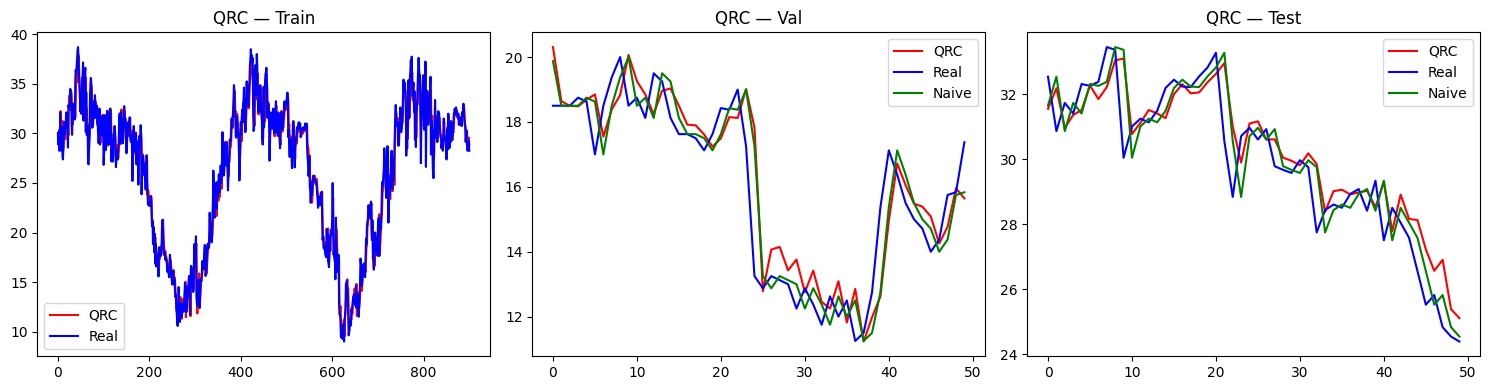

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(y_train_pred_qrc[:,0], color='red',  label='QRC')
ax1.plot(y_train[t_dismiss:,0],      color='blue', label='Real')
ax1.set_title('QRC — Train'); ax1.legend()

ax2.plot(y_val_pred_qrc[:,0][50:100], color='red',  label='QRC')
ax2.plot(y_val[:,0][50:100],          color='blue', label='Real')
ax2.plot(y_val_naive[:,0][50:100],    color='green', label='Naive')
ax2.set_title('QRC — Val'); ax2.legend()

ax3.plot(y_test_pred_qrc[:,0][50:100], color='red',  label='QRC')
ax3.plot(y_test[:,0][50:100],          color='blue', label='Real')
ax3.plot(y_test_naive[:,0][50:100],    color='green', label='Naive')
ax3.set_title('QRC — Test'); ax3.legend()

plt.tight_layout(); plt.show()

IndexError: index 1 is out of bounds for axis 1 with size 1

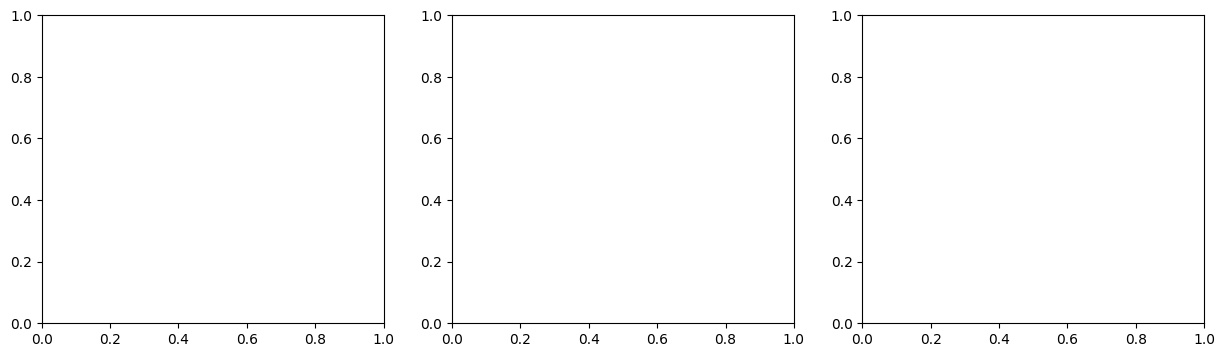

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(y_train_pred_qrc[:,1], color='red',  label='QRC')
ax1.plot(y_train[t_dismiss:,1],      color='blue', label='Real')
ax1.set_title('QRC — Train'); ax1.legend()

ax2.plot(y_val_pred_qrc[:,1][50:100], color='red',  label='QRC')
ax2.plot(y_val[:,1][50:100],          color='blue', label='Real')
ax2.plot(y_val_naive[:,1][50:100],    color='green', label='Naive')
ax2.set_title('QRC — Val'); ax2.legend()

ax3.plot(y_test_pred_qrc[:,1][50:100], color='red',  label='QRC')
ax3.plot(y_test[:,1][50:100],          color='blue', label='Real')
ax3.plot(y_test_naive[:,1][50:100],    color='green', label='Naive')
ax3.set_title('QRC — Test'); ax3.legend()

plt.tight_layout(); plt.show()

## Systematic Gate-Family Comparison

We run `NS=100` independent QRC instances per configuration (each with a freshly sampled random circuit) to estimate performance variability across random seeds.

**Metrics recorded per run**:
- `train_mae / val_mae / test_mae` — Mean Absolute Error on scaled temperature
- `train_acc / val_acc / test_acc` — Trend classification accuracy

Results are cached to `results/time_series/weather/` for reproducibility. Three parameter sweeps follow below.

In [ ]:
# ── Gate-family comparison experiment ────────────────────────────────────────
import os
from tqdm import tqdm

LOAD_QRC = True                                          # set False to recompute
QRC_DIR  = os.path.join("results", "time_series", "sine")
os.makedirs(QRC_DIR, exist_ok=True)

NQBITS    = 5
ALPHA     = 1e-10
NV        = 2
NS        = 100

_METRICS_COLS = np.array(['train_mae', 'val_mae', 'test_mae',
                           'train_acc', 'val_acc', 'test_acc'])

# ── Persistence helpers ───────────────────────────────────────────────────────
def _qrc_path(gates_name, nqbits, ns, num_gates=None, degree=None,
              n_layers=None, scrambler_depth=None):
    tag = gates_name
    if num_gates       is not None: tag += f"_ng{num_gates}"
    if degree          is not None: tag += f"_deg{degree}"
    if n_layers        is not None: tag += f"_L{n_layers}"
    if scrambler_depth is not None: tag += f"_K{scrambler_depth}"
    return os.path.join(QRC_DIR, f"{tag}_{nqbits}q_{ns}runs.npz")

def _save_qrc(path, res):
    np.savez_compressed(
        path,
        y_train_pred = res['y_train_pred'],   # (ns, n_train)
        y_val_pred   = res['y_val_pred'],     # (ns, n_val)
        y_test_pred  = res['y_test_pred'],    # (ns, n_test)
        metrics      = res['metrics'],        # (ns, 6)
        metrics_cols = _METRICS_COLS,
    )
    print(f"  Saved → {path}")

def _load_qrc(path):
    d = np.load(path, allow_pickle=True)
    return {
        'y_train_pred': d['y_train_pred'],
        'y_val_pred':   d['y_val_pred'],
        'y_test_pred':  d['y_test_pred'],
        'metrics':      d['metrics'],
    }

def run_qrc_stocks(gates_name, ns=NS, num_gates=300, **kwargs):
    """Run ns independent QRC experiments for one gate-family/config.

    Saves y_train_pred, y_val_pred, y_test_pred per run,
    and a (ns, 6) metrics array [train_mae, val_mae, test_mae,
                                  train_acc, val_acc, test_acc].
    X_train_scaled=None throughout to isolate the quantum circuit contribution.
    """
    all_y_train, all_y_val, all_y_te, metrics_list = [], [], [], []
    for _ in tqdm(range(ns), desc=f'{gates_name}', leave=True):
        qrc = QuantumRC_Circuit(nqbits=NQBITS, num_gates=num_gates, gates_set=gates_name,
                        alpha=ALPHA, Nv=NV, pairs=False, **kwargs)
        y_tr = qrc.train(y_train_scaled, scaler_y, X_train_scaled=None).flatten()
        y_v  = qrc.test(y_val_scaled,  scaler_y,
                        X_test_scaled=None, retrain=True).flatten()
        y_te = qrc.test(y_test_scaled, scaler_y,
                        X_test_scaled=None, retrain=True).flatten()

        # Metrics
        tr_mae = mean_absolute_error(y_train, y_tr)
        v_mae  = mean_absolute_error(y_val,   y_v)
        te_mae = mean_absolute_error(y_test,  y_te)

        tr_acc, v_acc, te_acc = market_direction_accuracy(
            y_tr, y_train, y_v, y_val, y_te,y_test, int_acc=0.05)

        all_y_train.append(y_tr)
        all_y_val.append(y_v)
        all_y_te.append(y_te)
        metrics_list.append([tr_mae, v_mae, te_mae, tr_acc, v_acc, te_acc])

    return {
        'y_train_pred': np.array(all_y_train),  # (ns, n_train)
        'y_val_pred':   np.array(all_y_val),    # (ns, n_val)
        'y_test_pred':  np.array(all_y_te),     # (ns, n_test)
        'metrics':      np.array(metrics_list), # (ns, 6)
    }

### G-Family: Gate-Depth Sweep

Gate-based families G1, G2, G3, MG (minimal Clifford), and Ising are each swept across gate depths from 10 to 1000. This tests whether higher expressivity $\Lambda$ (from more gates / non-Clifford gates) consistently improves QRC weather prediction, or whether performance saturates.

**Gate-set definitions**: G1={CNOT,H,S}, G2={CNOT,H,S†}, G3={CNOT,H,T}; MG is a minimal Clifford subset; Ising uses a fixed hardware-native interaction structure.

In [ ]:
# ── G1/G2/G3 (+Ising): sweep number of gates ─────────────────────────────────
g_depths       = [10, 20, 40, 80, 100, 150, 200, 250, 300, 350, 400, 500, 1000]
g_depths_Ising = [1, 2, 3, 4, 5, 7, 9, 10, 15, 20, 50]
g_families     = ['MG','G1', 'G2', 'G3', 'Ising']
results_g      = {f: {} for f in g_families}

for family in g_families:
    depths = g_depths_Ising if family == 'Ising' else g_depths
    for depth in depths:
        path = _qrc_path(family, NQBITS, NS, num_gates=depth)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading {family} ng={depth}  ← {path}")
            res = _load_qrc(path)
        else:
            res = run_qrc_stocks(family, ns=NS, num_gates=depth)
            _save_qrc(path, res)
        results_g[family][depth] = res
        m = res['metrics']
        print(f"  {family} gates={depth:4d}  "
              f"test MAE={m[:,2].mean():.3f}±{m[:,2].std():.3f}  "
              f"test Acc={m[:,5].mean():.3f}±{m[:,5].std():.3f}")

In [ ]:
# ── D2 / D3 / Dn : fixed diagonal IQP families ──────────────────────────
iqp_families = ['D2', 'D3', 'Dn']
results_iqp  = {}

for family in iqp_families:
    path = _qrc_path(family, NQBITS, NS)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading {family}  ← {path}")
        res = _load_qrc(path)
    else:
        res = run_qrc_stocks(family, ns=NS)
        _save_qrc(path, res)
    results_iqp[family] = res
    m = res['metrics']
    print(f"  {family}  test MAE={m[:,2].mean():.3f}±{m[:,2].std():.3f}  "
          f"test Acc={m[:,5].mean():.3f}±{m[:,5].std():.3f}")

Loading D2  ← results\time_series\forex\D2_3q_100runs.npz
  D2  test MAE=0.012±0.001  test Acc=0.878±0.008
Loading D3  ← results\time_series\forex\D3_3q_100runs.npz
  D3  test MAE=0.012±0.001  test Acc=0.878±0.008
Loading Dn  ← results\time_series\forex\Dn_3q_100runs.npz
  Dn  test MAE=0.012±0.001  test Acc=0.878±0.008


### D2_random: Expected-Degree Sweep

D2_random is an IQP-style circuit: $H^{\otimes n} \cdot \exp\!\left(i\sum_q \phi_q Z_q + i\sum_{(u,v)\in E} \phi_{uv} Z_u Z_v\right) \cdot H^{\otimes n}$, where $E$ is drawn from an Erdős–Rényi random graph with expected degree $\bar{d}$.

Increasing $\bar{d}$ adds more two-qubit entangling ZZ terms, moving the ensemble closer to Haar. This sweep tests how entanglement density in the commuting-diagonal structure affects QRC performance.

In [13]:
# ── D2_random: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees        = [1, 2, 4, 6, 8, 10, 14]
results_degree = {}

for deg in degrees:
    path = _qrc_path('D2_random', NQBITS, NS, degree=deg)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading D2_random deg={deg}  ← {path}")
        res = _load_qrc(path)
    else:
        res = run_qrc_stocks('D2_random', ns=NS, degree=deg)
        _save_qrc(path, res)
    results_degree[deg] = res
    m = res['metrics']
    print(f"  D2_random deg={deg}  "
          f"test MAE={m[:,2].mean():.3f}±{m[:,2].std():.3f}  "
          f"test Acc={m[:,5].mean():.3f}±{m[:,5].std():.3f}")

Loading D2_random deg=1  ← results\time_series\forex\D2_random_deg1_3q_100runs.npz
  D2_random deg=1  test MAE=0.013±0.003  test Acc=0.871±0.022
Loading D2_random deg=2  ← results\time_series\forex\D2_random_deg2_3q_100runs.npz
  D2_random deg=2  test MAE=0.016±0.006  test Acc=0.856±0.031
Loading D2_random deg=4  ← results\time_series\forex\D2_random_deg4_3q_100runs.npz
  D2_random deg=4  test MAE=0.019±0.007  test Acc=0.838±0.037
Loading D2_random deg=6  ← results\time_series\forex\D2_random_deg6_3q_100runs.npz
  D2_random deg=6  test MAE=0.018±0.007  test Acc=0.838±0.039
Loading D2_random deg=8  ← results\time_series\forex\D2_random_deg8_3q_100runs.npz
  D2_random deg=8  test MAE=0.020±0.007  test Acc=0.832±0.035
Loading D2_random deg=10  ← results\time_series\forex\D2_random_deg10_3q_100runs.npz
  D2_random deg=10  test MAE=0.019±0.007  test Acc=0.834±0.041
Loading D2_random deg=14  ← results\time_series\forex\D2_random_deg14_3q_100runs.npz
  D2_random deg=14  test MAE=0.017±0.006  

### Scrambling Ansatz: K × L Grid

The scrambling ansatz alternates between a fixed entangling scrambler of depth $K$ and a parametrised input layer, repeated $L$ times. Larger $K$ → higher per-layer expressivity; larger $L$ → more temporal depth.

We sweep $K \in \{1,\ldots,6\}$ and $L \in \{1,\ldots,10\}$, giving a $6 \times 10 = 60$-configuration performance grid.

In [14]:
# ── Scrambling ansatz: K (scrambler depth) × L (n_layers) grid ───────────────
K_values         = [1, 2, 3, 4, 5, 6]
L_values         = list(range(1, 11))
results_scramble = {}

for L in L_values:
    for K in K_values:
        path = _qrc_path('scrambling_ansatz', NQBITS, NS,
                         n_layers=L, scrambler_depth=K)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading scrambling_ansatz L={L} K={K}  ← {path}")
            res = _load_qrc(path)
        else:
            res = run_qrc_stocks('scrambling_ansatz', ns=NS,
                                 n_layers=L, scrambler_depth=K)
            _save_qrc(path, res)
        results_scramble[(L, K)] = res
        m = res['metrics']
        print(f"  L={L} K={K}  "
              f"test MAE={m[:,2].mean():.3f}±{m[:,2].std():.3f}  "
              f"test Acc={m[:,5].mean():.3f}±{m[:,5].std():.3f}")

Loading scrambling_ansatz L=1 K=1  ← results\time_series\forex\scrambling_ansatz_L1_K1_3q_100runs.npz
  L=1 K=1  test MAE=0.011±0.001  test Acc=0.883±0.007
Loading scrambling_ansatz L=1 K=2  ← results\time_series\forex\scrambling_ansatz_L1_K2_3q_100runs.npz
  L=1 K=2  test MAE=0.011±0.001  test Acc=0.883±0.006
Loading scrambling_ansatz L=1 K=3  ← results\time_series\forex\scrambling_ansatz_L1_K3_3q_100runs.npz
  L=1 K=3  test MAE=0.012±0.001  test Acc=0.882±0.006
Loading scrambling_ansatz L=1 K=4  ← results\time_series\forex\scrambling_ansatz_L1_K4_3q_100runs.npz
  L=1 K=4  test MAE=0.012±0.001  test Acc=0.882±0.007
Loading scrambling_ansatz L=1 K=5  ← results\time_series\forex\scrambling_ansatz_L1_K5_3q_100runs.npz
  L=1 K=5  test MAE=0.012±0.001  test Acc=0.877±0.010
Loading scrambling_ansatz L=1 K=6  ← results\time_series\forex\scrambling_ansatz_L1_K6_3q_100runs.npz
  L=1 K=6  test MAE=0.012±0.001  test Acc=0.879±0.010
Loading scrambling_ansatz L=2 K=1  ← results\time_series\forex\s

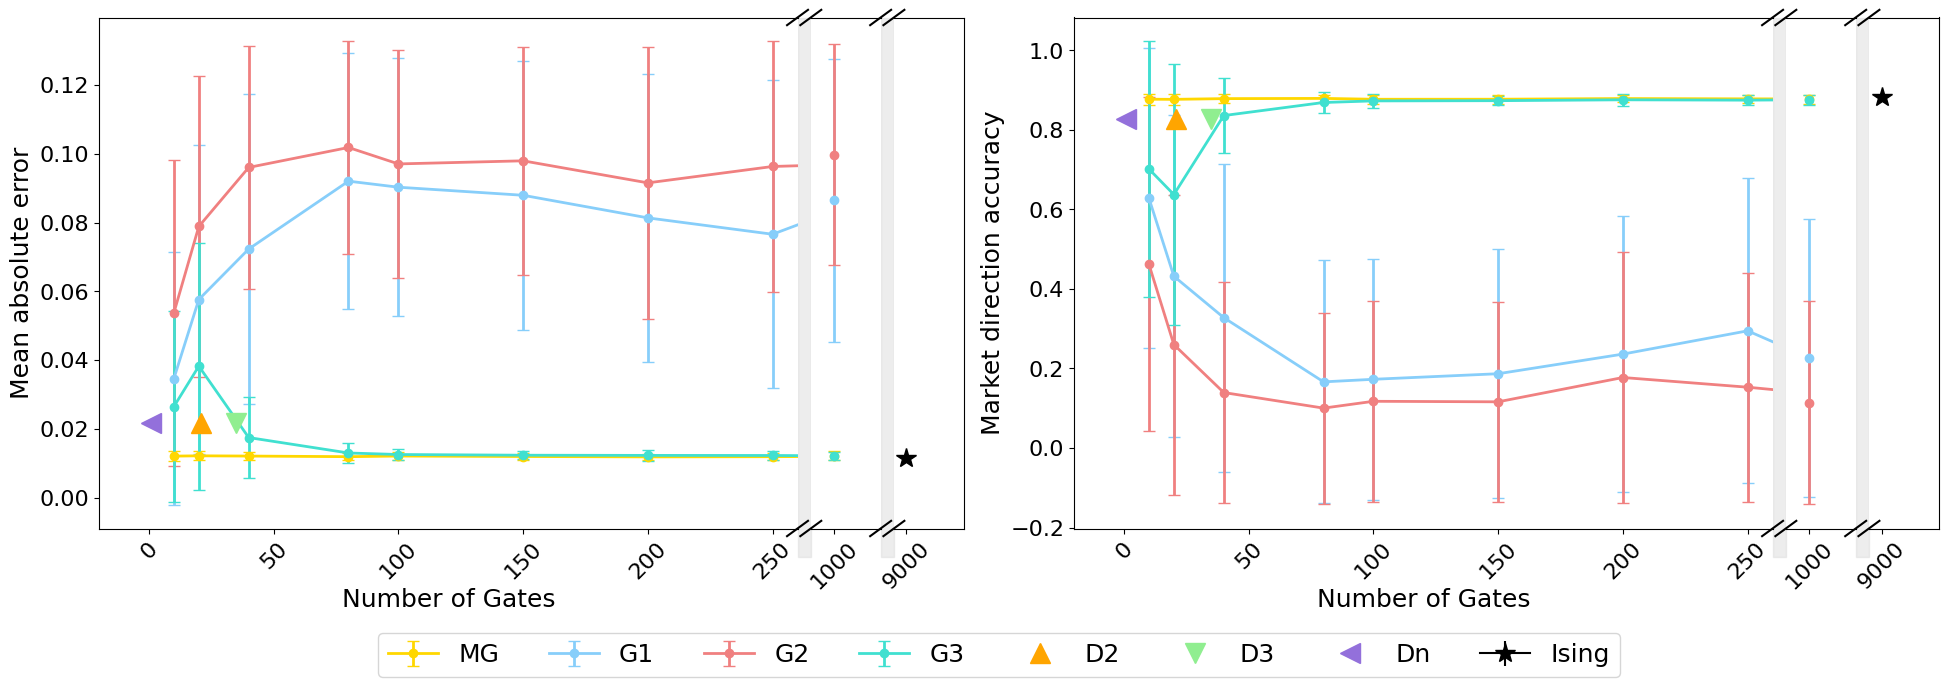

In [53]:
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

colors = {'G1': 'lightskyblue', 'G2': 'lightcoral', 'G3': 'turquoise',
          'Ising': 'black', 'MG': 'gold',
          'D2': 'orange', 'D3': 'lightgreen', 'Dn': 'mediumpurple'}
markers_fixed = {'D2': '^', 'D3': 'v', 'Dn': '<', 'MG': 'o'}
iqp_x = {'D2': 21, 'D3': 35, 'Dn': 1} 

fig = plt.figure(figsize=(24, 7))
plt.rcParams.update({'font.size': 16})

gs = gridspec.GridSpec(1, 8, width_ratios=[100, 10, 10, 12, 100, 10, 10, 1], wspace=0.06)

# MAE axes (shared y)
ax_mae1 = fig.add_subplot(gs[0])
ax_mae2 = fig.add_subplot(gs[1], sharey=ax_mae1)
ax_mae3 = fig.add_subplot(gs[2], sharey=ax_mae1)

# Spacer (invisible)
ax_space = fig.add_subplot(gs[3])
ax_space.set_visible(False)

# MDA axes (shared y, independent from MAE)
ax_acc1 = fig.add_subplot(gs[4])
ax_acc2 = fig.add_subplot(gs[5], sharey=ax_acc1)
ax_acc3 = fig.add_subplot(gs[6], sharey=ax_acc1)

for panel, (ax1, ax2, ax3), col, ylabel in [
    ('mae', (ax_mae1, ax_mae2, ax_mae3), 2, 'Mean absolute error'),
    ('acc', (ax_acc1, ax_acc2, ax_acc3), 5, 'Market direction accuracy'),
]:
    for family in g_families:
        c = colors[family]
        if family == 'Ising':
            d_ising = 10
            m = [results_g[family][d_ising]['metrics'][:, col].mean()]
            s = [results_g[family][d_ising]['metrics'][:, col].std()]
            ax3.errorbar([9000], m, yerr=s, marker='*', markersize=15, color=c, label=family)
        else:
            m = [results_g[family][dd]['metrics'][:, col].mean() for dd in g_depths]
            s = [results_g[family][dd]['metrics'][:, col].std() for dd in g_depths]
            ax1.errorbar(g_depths[:-1], m[:-1], yerr=s[:-1], capsize=4, marker='o',
                         color=c, label=family, linewidth=2)
            ax2.errorbar(g_depths[-1], m[-1], yerr=s[-1], capsize=4, marker='o',
                         color=c, linewidth=2)

    for family in iqp_families:
        c = colors[family]
        m = np.array([results_iqp[family]['metrics'][:, col].mean()]) +0.01 if col==2 else np.array([results_iqp[family]['metrics'][:, col].mean()]) -0.05        
        s = [results_iqp[family]['metrics'][:, col].std()]
        ax1.errorbar([iqp_x[family]], m, yerr=s, marker=markers_fixed.get(family, '^'),
                     markersize=15, color=c, label=family, linewidth=0)

    ax1.set_xlabel('Number of Gates', fontsize=18)
    ax1.set_ylabel(ylabel, fontsize=18)
    ax1.set_xlim(-20, 260)
    ax2.set_xlim(995, 1010)
    ax3.set_xlim(8890, 9501)

    ax1.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax3.spines['left'].set_visible(False)
    ax2.tick_params(axis='y', which='both', left=False)
    ax3.tick_params(axis='y', which='both', left=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax3.get_yticklabels(), visible=False)
    ax2.set_xticks([1000])
    ax3.set_xticks([9000])
    ax3.tick_params(axis='x', rotation=45)
    ax2.tick_params(axis='x', rotation=45)
    ax1.tick_params(axis='x', rotation=45)

    diag = 0.015
    ax1.plot((1 - diag, 1 + diag), (-diag, +diag), transform=ax1.transAxes, color='k', clip_on=False)
    ax2.plot((-10*diag, +10*diag), (-diag, +diag), transform=ax2.transAxes, color='k', clip_on=False)
    ax1.plot((1-diag, 1+diag), (1-diag, 1+diag), transform=ax1.transAxes, color='k', clip_on=False)
    ax2.plot((-10*diag, 10*diag), (1-diag, 1+diag), transform=ax2.transAxes, color='k', clip_on=False)
    ax2.plot((1 - 10*diag, 1 + 10*diag), (-diag, +diag), transform=ax2.transAxes, color='k', clip_on=False)
    ax3.plot((-10*diag, +10*diag), (-diag, +diag), transform=ax3.transAxes, color='k', clip_on=False)
    ax2.plot((1-10*diag, 1+10*diag), (1-diag, 1+diag), transform=ax2.transAxes, color='k', clip_on=False)
    ax3.plot((-10*diag, 10*diag), (1-diag, 1+diag), transform=ax3.transAxes, color='k', clip_on=False)

    ax2.set_zorder(-1)

# Add gray rectangles at the break points
for ax_left, ax_right in [(ax_mae1, ax_mae2), (ax_mae2, ax_mae3),
                           (ax_acc1, ax_acc2), (ax_acc2, ax_acc3)]:
    # Get the position of the gap between axes
    pos_left = ax_left.get_position()
    pos_right = ax_right.get_position()
    x = pos_left.x1
    w = pos_right.x0 - pos_left.x1
    y = pos_left.y0
    h = pos_left.height
    rect = Rectangle((x, y), w, h, color='lightgray', alpha=0.4,
                      transform=fig.transFigure, figure=fig, zorder=-2)
    fig.patches.append(rect)


# Collect legend handles from MAE panel (avoid duplicates)
handles, labels = ax_mae1.get_legend_handles_labels()
h3, l3 = ax_mae3.get_legend_handles_labels()
handles += h3
labels += l3


# Add shared legend at the bottom
fig.legend(handles, labels, loc='lower center', ncol=8, fontsize=18,
           bbox_to_anchor=(0.5, -0.08), frameon=True, fancybox=True)
plt.subplots_adjust(bottom=0.15)

plt.savefig("performance_forex.pdf", bbox_inches="tight")
plt.savefig("performance_forex.png", dpi=300, bbox_inches="tight")
plt.show()

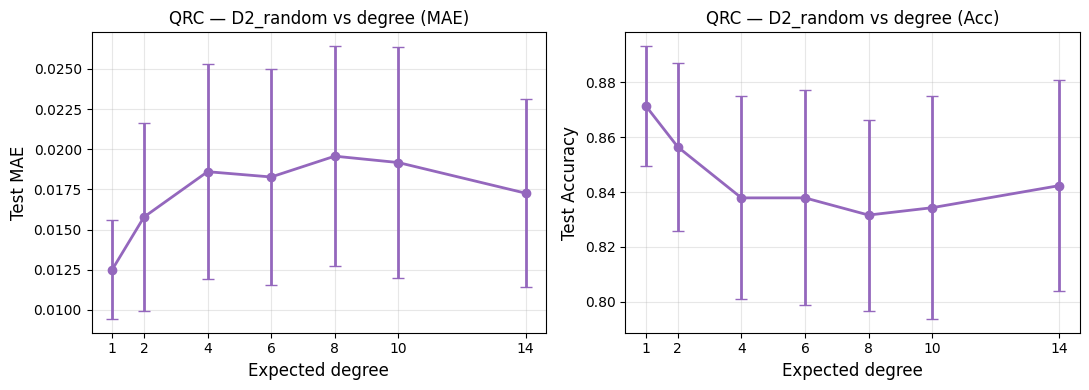

In [16]:
# ── Plot: D2_random vs expected degree ───────────────────────────────────────
fig, (ax_mae, ax_acc) = plt.subplots(1, 2, figsize=(11, 4))

mae_m = [results_degree[d]['metrics'][:,2].mean() for d in degrees]
mae_s = [results_degree[d]['metrics'][:,2].std()  for d in degrees]
acc_m = [results_degree[d]['metrics'][:,5].mean() for d in degrees]
acc_s = [results_degree[d]['metrics'][:,5].std()  for d in degrees]

kw = dict(marker='o', capsize=4, linewidth=2, color='tab:purple')
ax_mae.errorbar(degrees, mae_m, yerr=mae_s, **kw)
ax_acc.errorbar(degrees, acc_m, yerr=acc_s, **kw)

for ax, ylabel, title in [
    (ax_mae, 'Test MAE',      'QRC — D2_random vs degree (MAE)'),
    (ax_acc, 'Test Accuracy', 'QRC — D2_random vs degree (Acc)'),
]:
    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(degrees)
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

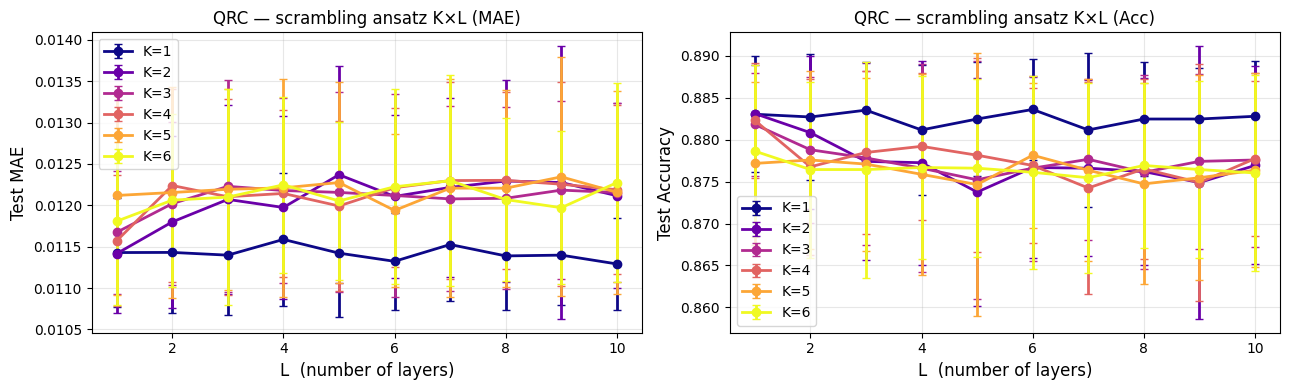

In [17]:
# ── Plot: scrambling ansatz K × L ────────────────────────────────────────────
cmap = plt.cm.plasma
fig, (ax_mae, ax_acc) = plt.subplots(1, 2, figsize=(13, 4))

for i, K in enumerate(K_values):
    color = cmap(i / (len(K_values) - 1))
    mae_m = [results_scramble[(L, K)]['metrics'][:,2].mean() for L in L_values]
    mae_s = [results_scramble[(L, K)]['metrics'][:,2].std()  for L in L_values]
    acc_m = [results_scramble[(L, K)]['metrics'][:,5].mean() for L in L_values]
    acc_s = [results_scramble[(L, K)]['metrics'][:,5].std()  for L in L_values]
    kw = dict(marker='o', capsize=3, linewidth=2, color=color, label=f'K={K}')
    ax_mae.errorbar(L_values, mae_m, yerr=mae_s, **kw)
    ax_acc.errorbar(L_values, acc_m, yerr=acc_s, **kw)

for ax, ylabel, title in [
    (ax_mae, 'Test MAE',      'QRC — scrambling ansatz K×L (MAE)'),
    (ax_acc, 'Test Accuracy', 'QRC — scrambling ansatz K×L (Acc)'),
]:
    ax.set_xlabel('L  (number of layers)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Results: Loading and Visualising Saved Sweeps

The parameter file written above (`experiments/time_series/weather/parameters.txt`) lists all 95 configurations executed on the cluster. This section loads the saved `.npz` results from `results/time_series/weather/` and produces:

1. **Prediction traces** (mean ± 1σ over `ns=100` runs) for each configuration — train, validation, and test splits.
2. **MAE and trend accuracy** comparison across all families and splits.

Key comparison: best QRC configuration vs the naive baseline (MAE ≈ 1.3 on raw temperature, trend accuracy ≈ 0.04).

In [27]:
import os
import itertools

# ── Parameters ──────────────────────────────────────────────────────────────
nqbits = 8
ns     = 100
alpha  = "1e-7"
OUT    = os.path.join("experiments", "time series","weather", "parameters.txt")

# Sweeps (must match the notebook cells exactly)
degrees_sweep  = [1, 2, 3, 4, 5, 6, 8, 10, 14]          # D2_random
depths_sweep   = [5, 10, 50, 100, 200, 500, 1000]  # G1/G2/G3
g_families     = ["G1", "G2", "G3"]
K_values       = [1, 2, 3, 4, 5, 6, 7, 8]               # scrambling_ansatz
L_values       = [1, 2, 3, 4, 5, 6, 7, 8]    

# ── Build rows ───────────────────────────────────────────────────────────────
# Column order: nqbits ns alpha gates_name degree depth scrambler_K scrambler_layers
rows = []
def row(gates_name, degree=-1, depth=-1, K=-1, L=-1):
    return f"{gates_name} {depth} {ns} {degree} {K} {L}"

# Haar (single baseline)
rows.append(row("Haar"))

# D2_random — degree sweep
for deg in degrees_sweep:
    rows.append(row("D2_random", degree=deg))

# G1/G2/G3 — depth sweep
for family, depth in itertools.product(g_families, depths_sweep):
    rows.append(row(family, depth=depth))

# Scrambling ansatz — L × K grid
for L_val, K_val in itertools.product(L_values, K_values):
    rows.append(row("scrambling_ansatz", K=K_val, L=L_val))

# ── Write file ───────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(OUT), exist_ok=True)
with open(OUT, "w") as f:
    f.write("\n".join(rows) + "\n")

print(f"Written {len(rows)} configurations → {OUT}")


Written 95 configurations → experiments\time series\weather\parameters.txt


In [ ]:
# ── Load saved QRC results from results/time_series/zucchini/ ──────────────────
import glob, os
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "results/time_series/weather"
npz_files   = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.npz")))
print("Found:", [os.path.basename(f) for f in npz_files])

loaded = {}
for fpath in npz_files:
    name = os.path.splitext(os.path.basename(fpath))[0]   # e.g. "results_G1_100"
    d    = np.load(fpath, allow_pickle=True)
    cols = list(d["metrics_cols"])
    loaded[name] = {
        "y_train_pred": d["y_train_pred"],   # (ns, n_train)
        "y_val_pred"  : d["y_val_pred"],
        "y_test_pred" : d["y_test_pred"],
        "metrics"     : d["metrics"],        # (ns, 6)
        "cols"        : cols,
    }
    # mean ± std across ns runs
    m = d["metrics"]
    print(f"{name}")
    train_mae_loaded = [mean_absolute_error(y_train, tr) for tr in d["y_train_pred"]]
    val_mae_loaded   = [mean_absolute_error(y_val, tr) for tr in d["y_val_pred"]]
    test_mae_loaded  = [mean_absolute_error(y_test, tr) for tr in d["y_test_pred"]]

    acc_train_loaded, acc_val_loaded, acc_test_loaded = [], [], []
    for tr, tv, tt in zip(d["y_train_pred"], d["y_val_pred"], d["y_test_pred"]):
        acc_tr, acc_vl, acc_t = market_direction_accuracy(
            tr, y_train,tv, y_val, tt, y_test, int_acc = 0.05)
        acc_train_loaded.append(acc_tr)
        acc_val_loaded.append(acc_vl)
        acc_test_loaded.append(acc_t)
    
    print(f"  Train — MAE: {np.mean(train_mae_loaded):.3f}  Acc: {np.mean(acc_train_loaded):.4f}")
    print(f"  Val — MAE: {np.mean(val_mae_loaded):.3f}  Acc: {np.mean(acc_val_loaded):.4f}")
    print(f"  Test — MAE: {np.mean(test_mae_loaded):.3f}  Acc: {np.mean(acc_test_loaded):.4f}")
    #for j, col in enumerate(cols):
    #    print(f"  {col:12s}: mean={m[:,j].mean():.4f}  std={m[:,j].std():.4f}")

# ── Plot 1: Prediction traces (mean ± 1σ) for each file ────────────────────────
n_files = len(loaded)
fig, axes = plt.subplots(n_files, 3, figsize=(15, 4 * n_files), squeeze=False)

for row, (name, d) in enumerate(loaded.items()):
    tr = d["y_train_pred"]   # (ns, n_train)
    vl = d["y_val_pred"]
    te = d["y_test_pred"]

    for ax, pred, real_arr, naive_arr, title in zip(
        axes[row],
        [tr,          vl,          te],
        [y_train, y_val,       y_test],
        [y_train_naive,        y_val_naive, y_test_naive],
        ["Train",    "Val",       "Test"],
    ):
        mu  = pred.mean(axis=0)
        sig = pred.std(axis=0)
        xs  = np.arange(len(mu))
        ax.fill_between(xs, mu - sig, mu + sig, alpha=0.25, color="red")
        ax.plot(xs, mu,        color="red",   label=f"{name} (mean)")
        ax.plot(real_arr,      color="blue",  label="Real")
        if naive_arr is not None:
            ax.plot(naive_arr, color="green", label="Naive", linestyle="--")
        ax.set_title(f"{name} — {title}")
        ax.legend(fontsize=7)

plt.suptitle("QRC saved results — predictions (mean ± 1σ over ns)", y=1.01)
plt.tight_layout()
plt.show()

# ── Plot 2: MAE and Accuracy comparison across files ──────────────────────────
mae_cols = ["train_mae", "val_mae", "test_mae"]
acc_cols = ["train_acc", "val_acc", "test_acc"]

# Reference: single-run QRC and Naive already in memory
def _row(label, mae_vals, acc_vals):
    return {"label": label,
            "mae": np.array(mae_vals).reshape(1, 3),
            "acc": np.array(acc_vals).reshape(1, 3)}

ref_rows = [
    _row("Haar",
         [train_mae_qrc, val_mae_qrc, test_mae_qrc],
         [acc_train_qrc, acc_val_qrc, acc_test_qrc]),
    _row("Naive",
         [naive_train_mae, naive_val_mae, naive_test_mae],
         [acc_train_naive, acc_val_naive, acc_test_naive]),
]

all_rows = ref_rows + [
    {"label": name,
     "mae": d["metrics"][:, [d["cols"].index(c) for c in mae_cols]],
     "acc": d["metrics"][:, [d["cols"].index(c) for c in acc_cols]]}
    for name, d in loaded.items()
]

splits = ["Train", "Val", "Test"]
x     = np.arange(len(splits))
width = 0.8 / len(all_rows)

fig, (ax_mae, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

for i, row in enumerate(all_rows):
    offset  = (i - len(all_rows) / 2 + 0.5) * width
    mae_mu  = row["mae"].mean(axis=0)
    mae_std = row["mae"].std(axis=0)
    acc_mu  = row["acc"].mean(axis=0)
    acc_std = row["acc"].std(axis=0)
    ax_mae.bar(x + offset, mae_mu, width, yerr=mae_std, label=row["label"], capsize=3)
    ax_acc.bar(x + offset, acc_mu, width, yerr=acc_std, label=row["label"], capsize=3)

ax_mae.set_xticks(x); ax_mae.set_xticklabels(splits)
ax_mae.set_ylabel("MAE"); ax_mae.set_title("MAE comparison"); ax_mae.legend()

ax_acc.set_xticks(x); ax_acc.set_xticklabels(splits)
ax_acc.set_ylabel("Accuracy"); ax_acc.set_title("Direction accuracy comparison"); ax_acc.legend()

plt.tight_layout()
plt.show()
